# Co-Registration Shift Compensation: is ZNCC depressed by misalignment?

Applies the Co-registration Shift Compensation (CSC) idea from
Sebastianelli et al. (2022), *Spatio-Temporal SAR-Optical Data Fusion for
Cloud Removal via a Deep Hierarchical Model*, Sec. IV-B eqs. 20a/20b, to
this project's weakest metric.

**Their argument.** Metrics computed between two co-registered sources are
depressed by registration error in a way that has nothing to do with model
quality. Rather than co-registering everything (which they call unfeasible
and inefficient), they evaluate each metric over a range of spatial shifts
and report the best value:

> `M_CSC = min (or max) over (e1, e2) of M(GT, pred_shifted(e1, e2))`

**Why it matters here, specifically.** ZNCC is the metric most punished by
a spatial offset -- it is a *positionally sensitive* correlation, so a
translation decorrelates it fast, while RMSE over a demeaned field
degrades much more gently. The geometry makes this a live concern:
Sentinel-1 is ~10 m and is resampled onto the LiDAR's 1 m grid, so a
sub-pixel S1 geolocation error becomes several *LiDAR* pixels of offset.
Nothing in this project has ever checked for it.

**What the outcomes mean.**
- Peak ZNCC at (0, 0) -> alignment is fine. The low ZNCC is a genuine model
  limitation, and this notebook closes off an obvious reviewer question.
- Peak at a *consistent* nonzero offset across patches -> a systematic
  registration bias between the S1 and LiDAR patch grids. This would revise
  the headline number rather than merely caveat it, and the fix (re-extract
  with the offset corrected) is mechanical.
- Peak scattered randomly per patch with no consistent offset -> the shift
  is fitting noise, not correcting registration. Treat any apparent gain as
  an upper bound, not a result; report it as such.

**On honesty.** Taking a max over shifts is an optimistically biased
estimator: even pure noise improves under a max over 121 candidates. This
notebook therefore reports the shifted number *alongside* the unshifted one
and a permutation-style null, never in place of it. The headline metric for
the dissertation stays the unshifted value unless a consistent offset is
demonstrated.

**Model-agnostic.** Set `USE_DEM_MODEL` below to test either `09`'s
baseline or `dem_unet/03`'s DEM-conditioned checkpoint.

**This notebook does not execute automatically. Run cells top to bottom.**

## Setup

In [1]:
import os
import sys
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), 'CUDA is required. Run this notebook on the GPU environment.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4090


## Configuration

`USE_DEM_MODEL` picks which checkpoint to probe. Everything else matches
`pcrtc/09` / `dem_unet/03` exactly, so the unshifted ZNCC this notebook
computes should reproduce the number already on record -- that agreement is
itself the first check that nothing has drifted.

In [2]:
USE_DEM_MODEL = False   # False -> pcrtc/09 baseline; True -> dem_unet/03 DEM-conditioned

WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = WORKING_REPO / 'tessa_baseline'
REGION = 'tuk'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
DEM_DIR = WORKING_REPO / 'input_data' / 'dem_patches_tuk'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if USE_DEM_MODEL:
    CHECKPOINT_NAME = 's1_tuk_pcrtc_dem_realattrs_spatialsplit_unet_best.pth'
    RESULT_FILENAME = 's1_pcrtc_dem_csc_shift_sweep.json'
    MODEL_LABEL = 'dem_unet/03 (+ DEM)'
else:
    CHECKPOINT_NAME = 's1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth'
    RESULT_FILENAME = 's1_pcrtc_csc_shift_sweep.json'
    MODEL_LABEL = 'pcrtc/09 (no DEM)'

CONTEXT_K = 3
TARGET_HW = (256, 256)
BATCH_SIZE = 8
TIMESTEPS = 1000
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'
SEED = 42
LIDAR_SURVEY_DATE = __import__('datetime').date(2024, 4, 16)
BLOCK_SIZE_M = 1024.0
BUFFER_M = 150.0
VAL_FRACTION = 0.15
DEM_FEAT_CH = 16

# CSC sweep: +/- MAX_SHIFT LiDAR pixels (= metres) in both axes
MAX_SHIFT = 5           # 11 x 11 = 121 candidate offsets
N_PATCHES = 120         # subsample of the val split -- enough to see a consistent offset

print('Model under test:', MODEL_LABEL)
print('Checkpoint:', CHECKPOINT_DIR / CHECKPOINT_NAME)
assert (CHECKPOINT_DIR / CHECKPOINT_NAME).exists(), 'Checkpoint not found.'
print(f'Shift sweep: +/-{MAX_SHIFT} px in x and y -> {(2 * MAX_SHIFT + 1) ** 2} offsets per patch')

Model under test: pcrtc/09 (no DEM)
Checkpoint: /cs/student/project_msc/2025/aibh/jiayiche/checkpoints/s1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth
Shift sweep: +/-5 px in x and y -> 121 offsets per patch


## Imports and model definitions (verbatim from `09` / `03`)

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.model.blocks import DoubleConv
from src.diffusion.utils import timestep_embedding
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddim

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


class DEMConditionalUNet(ConditionalUNet):
    """ConditionalUNet + one additional, independent DEM conditioning branch."""

    def __init__(self, *args, dem_feat_ch=16, **kwargs):
        super().__init__(*args, **kwargs)
        self.dem_feat_ch = dem_feat_ch
        self.dem_encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.SiLU(),
            nn.Conv2d(16, dem_feat_ch, 3, padding=1), nn.SiLU(),
        )
        in_channels = kwargs.get('in_channels', 1)
        cond_channels = kwargs.get('cond_channels', 24)
        self.input_conv = DoubleConv(in_channels + cond_channels + dem_feat_ch, self.base_channels, self.embed_dim)

    def forward(self, x, cond_img, attrs, dem, t):
        B = x.size(0)
        k = self.cond_k
        A_per = self.attr_dim_per
        t_emb = self.time_mlp(timestep_embedding(t, self.embed_dim))
        attrs_kA = attrs.view(B, k, A_per)
        fused_cond = self.asap(cond_img, attrs_kA, k=k)
        dem_feat = self.dem_encoder(dem)
        x = torch.cat([x, fused_cond, dem_feat], dim=1)
        skips = []
        x = self.input_conv(x, t_emb)
        for down in self.downs:
            skips.append(x)
            x = down(x, t_emb)
        x = self.bottleneck_conv(x, t_emb)
        for up in self.ups:
            skip = skips.pop()
            x = up(x, skip, t_emb)
        return self.output_conv(x)


class DemBoundModel(nn.Module):
    def __init__(self, inner, dem):
        super().__init__()
        self.inner = inner
        self.dem = dem

    def forward(self, x, cond, attrs, t):
        return self.inner(x, cond, attrs, self.dem, t)

## Dataset (verbatim from `03`; the DEM field is simply unused when `USE_DEM_MODEL` is False)

In [4]:
def build_real_attrs(s1_path, times, context_k):
    attrs_path = s1_path / 'attrs.json'
    attrs_list = json.load(open(attrs_path)) if attrs_path.exists() else []
    vecs = []
    for time_path in times:
        idx = int(time_path.stem[1:])
        a = attrs_list[idx] if idx < len(attrs_list) else {}
        if a.get('acquisition_date'):
            import datetime as dt
            acq_date = dt.date.fromisoformat(a['acquisition_date'])
            age_norm = (acq_date - LIDAR_SURVEY_DATE).days / 30.0
        else:
            age_norm = 0.0
        orbit_dir = 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0
        rel_orbit = (a.get('relative_orbit_number') or 0) / 175.0
        vecs.append([age_norm, orbit_dir, rel_orbit, 0.0, 0.0, 0.0, 0.0, 0.0])
    return torch.tensor(vecs, dtype=torch.float32).flatten()


class LidarS1DemDataset(Dataset):
    def __init__(self, s1_dir, lidar_dir, dem_dir, patch_ids, context_k=3, target_hw=(256, 256), with_dem=True):
        self.s1_dir = Path(s1_dir)
        self.lidar_dir = Path(lidar_dir)
        self.dem_dir = Path(dem_dir)
        self.patch_ids = list(patch_ids)
        self.context_k = context_k
        self.target_hw = target_hw
        self.with_dem = with_dem

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        patch_id = self.patch_ids[index]
        with rasterio.open(self.lidar_dir / f'lidar_patch_{patch_id}.tif') as src:
            raw = src.read().astype(np.float32)
        target = raw[0]
        mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
        target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
        valid_count = max(1, int(mask.sum()))
        patch_mean = float(target[mask].sum() / valid_count)
        target = (target - patch_mean) * mask

        s1_path = self.s1_dir / f's1_patch_{patch_id}'
        times = sorted(s1_path.glob('t*.tif'))[:self.context_k]
        if len(times) < self.context_k:
            raise RuntimeError(f'{s1_path} has fewer than {self.context_k} Sentinel-1 times')
        views = []
        for time_path in times:
            with rasterio.open(time_path) as src:
                sar = src.read()[:2].astype(np.float32)
            sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
            sar = np.maximum(sar, 1e-12)
            sar = 10.0 * np.log10(sar)
            sar_tensor = torch.from_numpy(sar).unsqueeze(0)
            sar_tensor = F.interpolate(sar_tensor, size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
            sar_tensor = sar_tensor.repeat(2, 1, 1)
            views.append(sar_tensor)
        condition = torch.cat(views, dim=0)
        attrs = build_real_attrs(s1_path, times, self.context_k)

        if self.with_dem:
            with rasterio.open(self.dem_dir / f'dem_patch_{patch_id}.tif') as src:
                dem_arr = src.read(1).astype(np.float32)
            dem_arr = np.nan_to_num(dem_arr, nan=0.0, posinf=0.0, neginf=0.0)
            dem_arr = dem_arr - dem_arr.mean()
            dem_tensor = torch.from_numpy(dem_arr).unsqueeze(0)
            if dem_tensor.shape[-2:] != torch.Size(self.target_hw):
                dem_tensor = F.interpolate(dem_tensor.unsqueeze(0), size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
        else:
            dem_tensor = torch.zeros(1, *self.target_hw)

        return {
            'lidar': torch.from_numpy(target).unsqueeze(0).float(), 'mask': torch.from_numpy(mask),
            's1': condition.float(), 'attrs': attrs, 'dem': dem_tensor.float(),
            'patch_mean': torch.tensor(patch_mean), 'patch_id': patch_id,
        }

## Spatial-block split -- copied verbatim from `09`

Must be the same validation patches, or the unshifted ZNCC will not
reproduce the number on record and nothing below can be compared to it.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
assert paired_ids, 'No paired Sentinel-1/LiDAR patches found.'

if USE_DEM_MODEL:
    dem_ids = {p.stem.split('_')[-1] for p in DEM_DIR.glob('dem_patch_*.tif')}
    missing_dem = set(paired_ids) - dem_ids
    assert not missing_dem, f'{len(missing_dem)} paired patches have no DEM patch -- re-run 01 before continuing.'

def patch_centroid(patch_id):
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{patch_id}.tif') as src:
        b = src.bounds
    return ((b.left + b.right) / 2.0, (b.bottom + b.top) / 2.0)

centroids = {pid: patch_centroid(pid) for pid in paired_ids}

def block_id_and_boundary_distance(cx, cy, block_size):
    bx, by = int(cx // block_size), int(cy // block_size)
    dx = min(cx - bx * block_size, (bx + 1) * block_size - cx)
    dy = min(cy - by * block_size, (by + 1) * block_size - cy)
    return (bx, by), min(dx, dy)

blocks = {}
dropped_buffer = []
for pid, (cx, cy) in centroids.items():
    bid, boundary_dist = block_id_and_boundary_distance(cx, cy, BLOCK_SIZE_M)
    if boundary_dist < BUFFER_M:
        dropped_buffer.append(pid)
        continue
    blocks.setdefault(bid, []).append(pid)

block_ids = list(blocks.keys())
random.Random(SEED).shuffle(block_ids)

target_val_patches = int(len(paired_ids) * VAL_FRACTION)
val_ids, train_ids = [], []
running_val_count = 0
for bid in block_ids:
    if running_val_count < target_val_patches:
        val_ids.extend(blocks[bid])
        running_val_count += len(blocks[bid])
    else:
        train_ids.extend(blocks[bid])

print(f'Spatial-block split (matching pcrtc/09): train={len(train_ids)}, val={len(val_ids)} '
      f'(target val={target_val_patches}, {len(dropped_buffer)} dropped as buffer)')
assert len(train_ids) == 534 and len(val_ids) == 255, (
    f'Split is {len(train_ids)}/{len(val_ids)}, expected 534/255 to match 09 -- stop and investigate.')

sweep_ids = random.Random(7).sample(val_ids, min(N_PATCHES, len(val_ids)))
print(f'Sweeping {len(sweep_ids)} of {len(val_ids)} validation patches')

dataset = LidarS1DemDataset(S1_DIR, LIDAR_DIR, DEM_DIR, sweep_ids, CONTEXT_K, TARGET_HW, with_dem=USE_DEM_MODEL)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Spatial-block split (matching pcrtc/09): train=534, val=255 (target val=251, 887 dropped as buffer)
Sweeping 120 of 255 validation patches


## Load the checkpoint

In [6]:
if USE_DEM_MODEL:
    model = DEMConditionalUNet(
        in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128,
        embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K,
        dem_feat_ch=DEM_FEAT_CH).to(DEVICE)
else:
    model = ConditionalUNet(
        in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128,
        embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)

scheduler = LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE)
checkpoint = torch.load(CHECKPOINT_DIR / CHECKPOINT_NAME, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded {MODEL_LABEL}: epoch {checkpoint["epoch"]}, val_loss={checkpoint["val_loss"]:.6f}')

Loaded pcrtc/09 (no DEM): epoch 93, val_loss=0.013706


## The shift sweep

`zncc_shifted` crops both fields to a common interior window and slides the
*prediction* against the ground truth. Cropping (rather than padding or
wrapping) matters: padding would inject zeros that are not data, and
wrapping would correlate opposite edges of the patch, both of which
manufacture structure that is not there.

The mask is shifted with the prediction and intersected with the GT mask,
so only genuinely valid, genuinely overlapping pixels enter the
correlation at every offset.

In [7]:
def zncc_np(a, b):
    """Plain ZNCC over two 1-D arrays. Matches the definition Tessa's
    recon_metrics.zncc uses -- both fields demeaned and normalised, so
    absolute scale and offset are already stripped out."""
    if a.size < 32:
        return np.nan
    a = a - a.mean()
    b = b - b.mean()
    da, db = np.sqrt((a ** 2).sum()), np.sqrt((b ** 2).sum())
    if da < 1e-12 or db < 1e-12:
        return np.nan
    return float((a * b).sum() / (da * db))


def zncc_shifted(gt, pred, mask, dy, dx, margin):
    """ZNCC with pred translated by (dy, dx) relative to gt.
    Both are cropped to the same interior window so no invented pixels
    ever enter the correlation."""
    H, W = gt.shape
    y0, y1 = margin, H - margin
    x0, x1 = margin, W - margin
    gt_c = gt[y0:y1, x0:x1]
    m_gt = mask[y0:y1, x0:x1]
    pred_c = pred[y0 + dy:y1 + dy, x0 + dx:x1 + dx]
    m_pr = mask[y0 + dy:y1 + dy, x0 + dx:x1 + dx]
    both = m_gt & m_pr
    if both.sum() < 32:
        return np.nan
    return zncc_np(gt_c[both], pred_c[both])


offsets = [(dy, dx) for dy in range(-MAX_SHIFT, MAX_SHIFT + 1)
                    for dx in range(-MAX_SHIFT, MAX_SHIFT + 1)]
sampler = p_sample_loop_ddim
rows = []

with torch.no_grad():
    for batch in loader:
        target = batch['lidar'].to(DEVICE)
        condition = batch['s1'].to(DEVICE)
        attrs = batch['attrs'].to(DEVICE)
        mask_t = batch['mask'].to(DEVICE).bool()
        if USE_DEM_MODEL:
            dem = batch['dem'].to(DEVICE)
            net = DemBoundModel(model, dem)
        else:
            net = model
        prediction = sampler(net, scheduler, target.shape, condition, attrs, DEVICE)

        for i, patch_id in enumerate(batch['patch_id']):
            gt = target[i].squeeze().cpu().numpy()
            pr = prediction[i].squeeze().cpu().numpy()
            mk = mask_t[i].squeeze().cpu().numpy()
            surf = {}
            for (dy, dx) in offsets:
                surf[f'{dy},{dx}'] = zncc_shifted(gt, pr, mk, dy, dx, MAX_SHIFT)
            finite = {k: v for k, v in surf.items() if np.isfinite(v)}
            if not finite:
                continue
            best_key = max(finite, key=finite.get)
            bdy, bdx = (int(v) for v in best_key.split(','))
            rows.append({
                'patch_id': patch_id,
                'zncc_unshifted': surf['0,0'],
                'zncc_best': finite[best_key],
                'best_dy': bdy, 'best_dx': bdx,
                'surface': surf,
            })

print(f'Swept {len(rows)} patches x {len(offsets)} offsets')
result_path = OUTPUT_DIR / RESULT_FILENAME
with result_path.open('w') as handle:
    json.dump(rows, handle, indent=2)
print('Saved:', result_path)

Swept 120 patches x 121 offsets
Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_csc_shift_sweep.json


## Results

The question is not "does the max beat the unshifted value" -- it always
will, that is what a max over 121 candidates does. The question is whether
the best offsets **agree across patches**. A real registration bias points
the same way everywhere; noise does not.

In [8]:
unshifted = np.array([r['zncc_unshifted'] for r in rows], dtype=float)
best = np.array([r['zncc_best'] for r in rows], dtype=float)

print(f'Model: {MODEL_LABEL}   patches: {len(rows)}')
print(f'Mean ZNCC, unshifted (0,0)      : {np.nanmean(unshifted):.4f}')
print(f'Mean ZNCC, per-patch best offset : {np.nanmean(best):.4f}   '
      f'(+{np.nanmean(best) - np.nanmean(unshifted):.4f}, upper bound -- optimistically biased)')

# Mean ZNCC at each offset: a SINGLE global shift applied to every patch.
# This is the honest estimator -- one offset for the whole dataset cannot
# fit per-patch noise the way a per-patch argmax can.
mean_surface = {}
for (dy, dx) in offsets:
    key = f'{dy},{dx}'
    vals = np.array([r['surface'][key] for r in rows], dtype=float)
    mean_surface[(dy, dx)] = float(np.nanmean(vals))

global_best = max(mean_surface, key=mean_surface.get)
print(f'\nBest SINGLE global offset: (dy={global_best[0]}, dx={global_best[1]})  '
      f'mean ZNCC {mean_surface[global_best]:.4f}')
print(f'Gain from the global shift: {mean_surface[global_best] - mean_surface[(0, 0)]:+.4f}')

# Do the per-patch argmaxes agree?
votes = Counter((r['best_dy'], r['best_dx']) for r in rows)
top = votes.most_common(5)
frac_at_zero = votes[(0, 0)] / len(rows)
print(f'\nPer-patch best offsets -- top 5 of {len(votes)} distinct:')
for (dy, dx), n in top:
    print(f'  (dy={dy:+d}, dx={dx:+d}): {n} patches ({n / len(rows):.0%})')
print(f'Patches whose best offset is exactly (0,0): {frac_at_zero:.0%}')
print(f'Uniform-noise expectation for any single offset: {1 / len(offsets):.1%}')

print('\n--- verdict ---')
if global_best == (0, 0):
    print('Peak of the global surface is at (0,0): NO systematic misregistration.')
    print('The low ZNCC is a genuine model limitation, not an alignment artifact.')
    print('Report the unshifted number; cite this sweep as having ruled the alternative out.')
elif votes[global_best] / len(rows) > 3 / len(offsets):
    print(f'Global peak at {global_best} and per-patch votes concentrate there '
          f'({votes[global_best] / len(rows):.0%}, vs {1 / len(offsets):.1%} expected by chance).')
    print('CONSISTENT registration offset. Worth re-extracting the patches with it corrected,')
    print('then re-running 09 -- this would revise the headline number, not just caveat it.')
else:
    print(f'Global peak at {global_best}, but per-patch best offsets are scattered '
          f'({len(votes)} distinct offsets, top one only {top[0][1] / len(rows):.0%}).')
    print('This looks like a max fitting noise, not a real registration bias.')
    print('Report the unshifted number as the headline and this gain as an upper bound only.')

Model: pcrtc/09 (no DEM)   patches: 120
Mean ZNCC, unshifted (0,0)      : 0.2264
Mean ZNCC, per-patch best offset : 0.2558   (+0.0293, upper bound -- optimistically biased)

Best SINGLE global offset: (dy=5, dx=0)  mean ZNCC 0.2323
Gain from the global shift: +0.0059

Per-patch best offsets -- top 5 of 49 distinct:
  (dy=+5, dx=+5): 18 patches (15%)
  (dy=+5, dx=-5): 17 patches (14%)
  (dy=+5, dx=+1): 5 patches (4%)
  (dy=-5, dx=-5): 5 patches (4%)
  (dy=-5, dx=+5): 5 patches (4%)
Patches whose best offset is exactly (0,0): 1%
Uniform-noise expectation for any single offset: 0.8%

--- verdict ---
Global peak at (5, 0), but per-patch best offsets are scattered (49 distinct offsets, top one only 15%).
This looks like a max fitting noise, not a real registration bias.
Report the unshifted number as the headline and this gain as an upper bound only.


## The shift surface

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_csc_shift_sweep.png


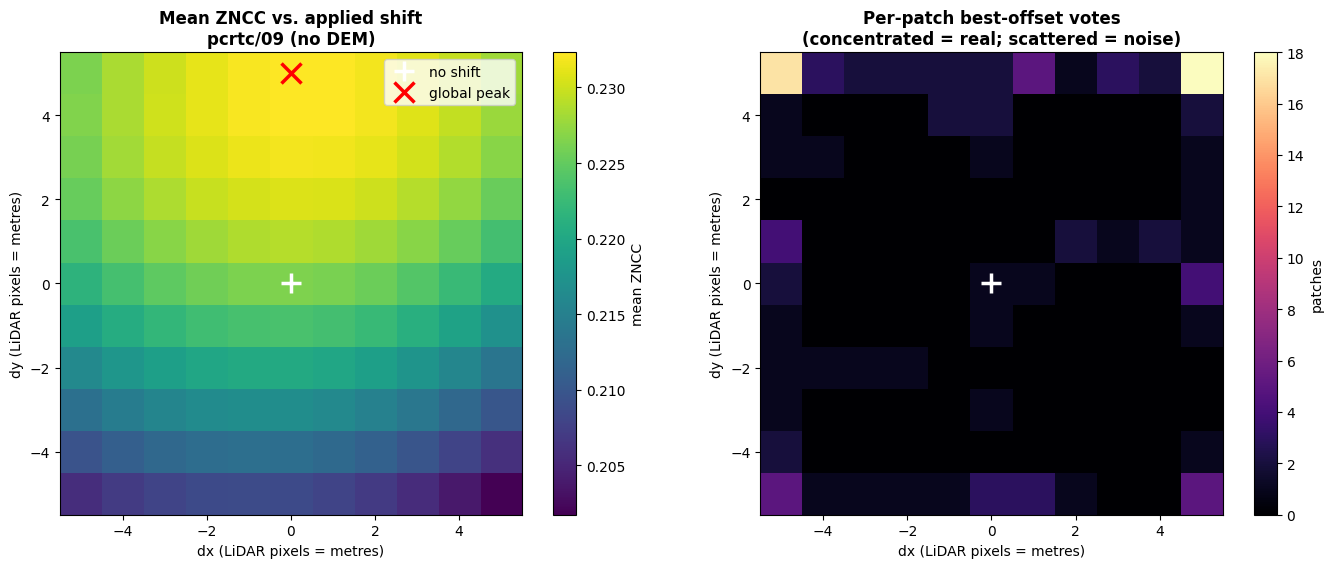

In [9]:
grid = np.full((2 * MAX_SHIFT + 1, 2 * MAX_SHIFT + 1), np.nan)
for (dy, dx), v in mean_surface.items():
    grid[dy + MAX_SHIFT, dx + MAX_SHIFT] = v

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im = axes[0].imshow(grid, cmap='viridis', origin='lower',
                    extent=[-MAX_SHIFT - .5, MAX_SHIFT + .5, -MAX_SHIFT - .5, MAX_SHIFT + .5])
axes[0].plot(0, 0, 'w+', markersize=14, markeredgewidth=2.5, label='no shift')
axes[0].plot(global_best[1], global_best[0], 'r x', markersize=14, markeredgewidth=2.5, label='global peak')
axes[0].set_xlabel('dx (LiDAR pixels = metres)')
axes[0].set_ylabel('dy (LiDAR pixels = metres)')
axes[0].set_title(f'Mean ZNCC vs. applied shift\n{MODEL_LABEL}', fontweight='bold')
axes[0].legend(loc='upper right')
fig.colorbar(im, ax=axes[0], label='mean ZNCC')

vote_grid = np.zeros_like(grid)
for (dy, dx), n in votes.items():
    vote_grid[dy + MAX_SHIFT, dx + MAX_SHIFT] = n
im2 = axes[1].imshow(vote_grid, cmap='magma', origin='lower',
                     extent=[-MAX_SHIFT - .5, MAX_SHIFT + .5, -MAX_SHIFT - .5, MAX_SHIFT + .5])
axes[1].plot(0, 0, 'w+', markersize=14, markeredgewidth=2.5)
axes[1].set_xlabel('dx (LiDAR pixels = metres)')
axes[1].set_ylabel('dy (LiDAR pixels = metres)')
axes[1].set_title('Per-patch best-offset votes\n(concentrated = real; scattered = noise)', fontweight='bold')
fig.colorbar(im2, ax=axes[1], label='patches')

plt.tight_layout()
out = OUTPUT_DIR / RESULT_FILENAME.replace('.json', '.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)
plt.show()